In [1]:
"""
Exploration du dataset GrandMidiPiano.
Objectif : comprendre la distribution des notes, durées et tempos
pour designer un tokenizer adapté.
"""

import os
from pathlib import Path
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from miditoolkit import MidiFile
from tqdm import tqdm

# Chemin vers les MIDI (relatif au notebook)
DATA_DIR = Path("../data/GrandMidiPiano")
assert DATA_DIR.exists(), f"Dossier introuvable : {DATA_DIR.resolve()}"

# Liste tous les fichiers .mid (récursif au cas où)
midi_files = list(DATA_DIR.rglob("*.mid")) + list(DATA_DIR.rglob("*.midi"))
print(f"Nombre de fichiers MIDI trouvés : {len(midi_files)}")
print(f"Exemple : {midi_files[0].name}")

Nombre de fichiers MIDI trouvés : 10855
Exemple : A., Jag, Je t_aime Juliette, OXC7Fd0ZN8o.mid


In [2]:
# On regarde le premier fichier en détail
mid = MidiFile(str(midi_files[0]))

print(f"Fichier : {midi_files[0].name}")
print(f"Ticks par beat (résolution) : {mid.ticks_per_beat}")
print(f"Nombre d'instruments : {len(mid.instruments)}")
print(f"Tempos : {len(mid.tempo_changes)} changement(s)")
print(f"Premier tempo : {mid.tempo_changes[0].tempo:.1f} BPM" if mid.tempo_changes else "")

# Notes du premier instrument (piano)
notes = mid.instruments[0].notes
print(f"\nNombre de notes : {len(notes)}")
print(f"5 premières notes :")
for n in notes[:5]:
    print(f"  pitch={n.pitch}, start={n.start}, end={n.end}, durée={n.end-n.start}, vélocité={n.velocity}")

Fichier : A., Jag, Je t_aime Juliette, OXC7Fd0ZN8o.mid
Ticks par beat (résolution) : 384
Nombre d'instruments : 1
Tempos : 1 changement(s)
Premier tempo : 120.0 BPM

Nombre de notes : 946
5 premières notes :
  pitch=48, start=471, end=476, durée=5, vélocité=63
  pitch=76, start=471, end=698, durée=227, vélocité=62
  pitch=45, start=463, end=852, durée=389, vélocité=73
  pitch=84, start=464, end=852, durée=388, vélocité=84
  pitch=76, start=703, end=860, durée=157, vélocité=68


In [3]:
# Stats globales
all_pitches = []
all_durations = []  # en ticks normalisés (par beat)
all_velocities = []
n_notes_per_file = []
ticks_per_beat_set = set()
tempos = []
errors = []

# On échantillonne 2000 fichiers pour aller vite (suffisant pour les stats)
SAMPLE_SIZE = min(2000, len(midi_files))
sampled = np.random.RandomState(42).choice(midi_files, SAMPLE_SIZE, replace=False)

for path in tqdm(sampled, desc="Analyse MIDI"):
    try:
        mid = MidiFile(str(path))
        ticks_per_beat_set.add(mid.ticks_per_beat)
        if mid.tempo_changes:
            tempos.append(mid.tempo_changes[0].tempo)
        
        # Concatène toutes les notes de tous les instruments
        notes = []
        for inst in mid.instruments:
            notes.extend(inst.notes)
        
        n_notes_per_file.append(len(notes))
        for n in notes:
            all_pitches.append(n.pitch)
            # Durée normalisée en quarts de noire (beat)
            all_durations.append((n.end - n.start) / mid.ticks_per_beat)
            all_velocities.append(n.velocity)
    except Exception as e:
        errors.append((path.name, str(e)))

print(f"\nFichiers analysés : {SAMPLE_SIZE}")
print(f"Erreurs : {len(errors)}")
print(f"Total notes : {len(all_pitches):,}")
print(f"Résolutions ticks/beat trouvées : {sorted(ticks_per_beat_set)}")
print(f"Tempos : min={min(tempos):.0f}, max={max(tempos):.0f}, moyen={np.mean(tempos):.0f} BPM")

Analyse MIDI: 100%|██████████| 2000/2000 [04:50<00:00,  6.90it/s]


Fichiers analysés : 2000
Erreurs : 0
Total notes : 7,088,801
Résolutions ticks/beat trouvées : [384]
Tempos : min=120, max=120, moyen=120 BPM


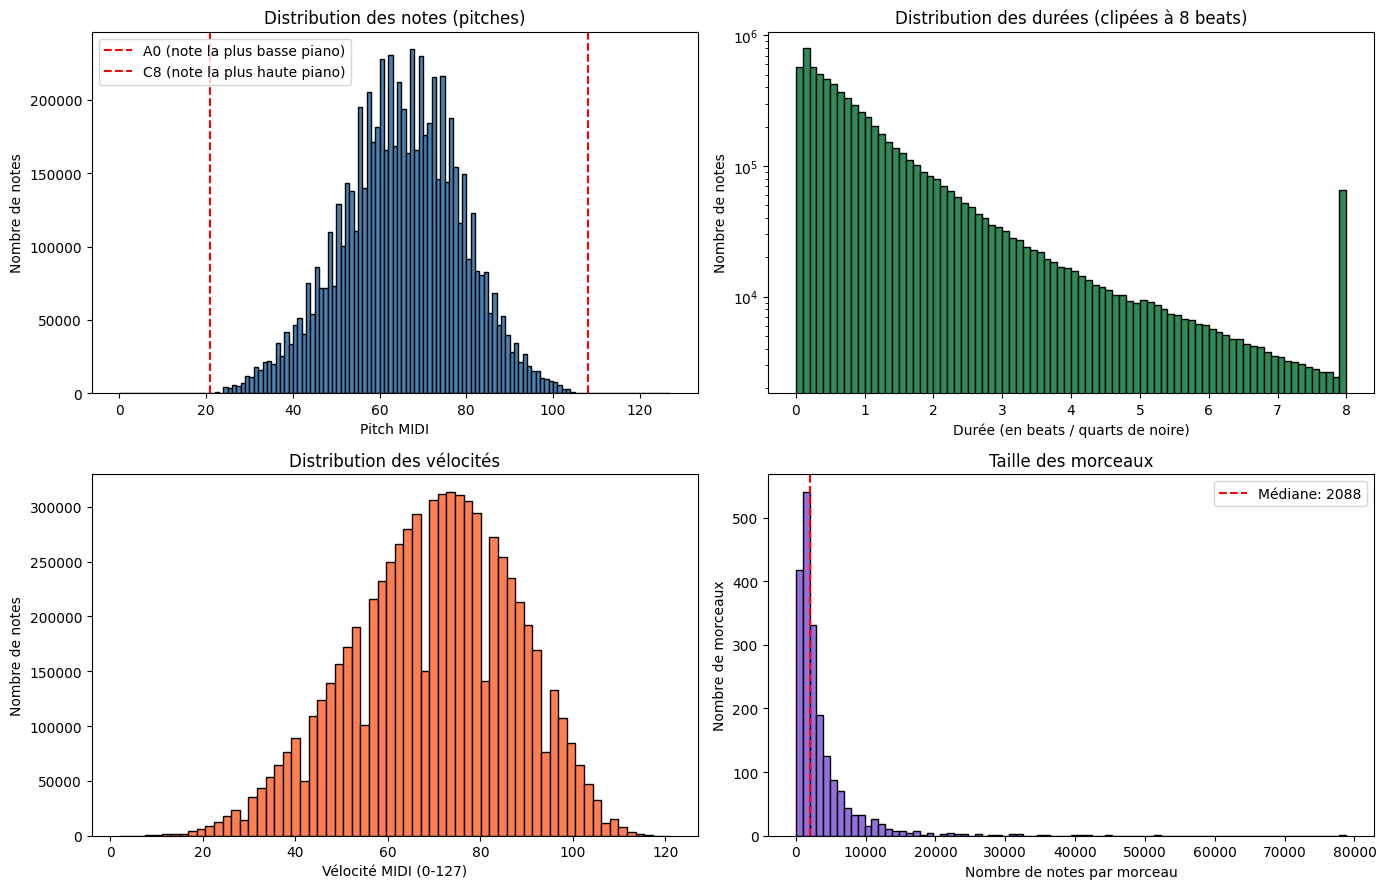

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Distribution des pitches (notes)
axes[0, 0].hist(all_pitches, bins=range(0, 128), color='steelblue', edgecolor='black')
axes[0, 0].axvline(21, color='red', linestyle='--', label='A0 (note la plus basse piano)')
axes[0, 0].axvline(108, color='red', linestyle='--', label='C8 (note la plus haute piano)')
axes[0, 0].set_xlabel('Pitch MIDI')
axes[0, 0].set_ylabel('Nombre de notes')
axes[0, 0].set_title('Distribution des notes (pitches)')
axes[0, 0].legend()

# 2. Distribution des durées (en beats, log scale)
axes[0, 1].hist(np.clip(all_durations, 0, 8), bins=80, color='seagreen', edgecolor='black')
axes[0, 1].set_xlabel('Durée (en beats / quarts de noire)')
axes[0, 1].set_ylabel('Nombre de notes')
axes[0, 1].set_title('Distribution des durées (clipées à 8 beats)')
axes[0, 1].set_yscale('log')

# 3. Distribution des vélocités
axes[1, 0].hist(all_velocities, bins=64, color='coral', edgecolor='black')
axes[1, 0].set_xlabel('Vélocité MIDI (0-127)')
axes[1, 0].set_ylabel('Nombre de notes')
axes[1, 0].set_title('Distribution des vélocités')

# 4. Notes par fichier
axes[1, 1].hist(n_notes_per_file, bins=80, color='mediumpurple', edgecolor='black')
axes[1, 1].axvline(np.median(n_notes_per_file), color='red', linestyle='--',
                   label=f'Médiane: {np.median(n_notes_per_file):.0f}')
axes[1, 1].set_xlabel('Nombre de notes par morceau')
axes[1, 1].set_ylabel('Nombre de morceaux')
axes[1, 1].set_title('Taille des morceaux')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('../outputs/exploration_stats.png', dpi=120, bbox_inches='tight')
plt.show()

In [5]:
print("=" * 60)
print("DÉCISIONS POUR LE TOKENIZER")
print("=" * 60)

p_low, p_high = np.percentile(all_pitches, [1, 99])
print(f"\nPitches : 1er percentile = {p_low:.0f}, 99e = {p_high:.0f}")
print(f"  → on couvre 21-108 (88 touches piano standard)")

d_50, d_95 = np.percentile(all_durations, [50, 95])
print(f"\nDurées : médiane = {d_50:.2f} beats, 95e percentile = {d_95:.2f} beats")
print(f"  → quantifier les durées en multiples de 1/16 de beat (sixteenth note)")
print(f"  → cap max à ~4 beats (clip)")

n_50, n_95 = np.percentile(n_notes_per_file, [50, 95])
print(f"\nNotes par morceau : médiane = {n_50:.0f}, 95e = {n_95:.0f}")
print(f"  → context_length de 256 ou 512 tokens raisonnable")

print(f"\nRésolutions trouvées : {sorted(ticks_per_beat_set)}")
print(f"  → on normalisera tout sur une grille en 1/16 de beat")

DÉCISIONS POUR LE TOKENIZER

Pitches : 1er percentile = 32, 99e = 95
  → on couvre 21-108 (88 touches piano standard)

Durées : médiane = 0.65 beats, 95e percentile = 3.85 beats
  → quantifier les durées en multiples de 1/16 de beat (sixteenth note)
  → cap max à ~4 beats (clip)

Notes par morceau : médiane = 2088, 95e = 11346
  → context_length de 256 ou 512 tokens raisonnable

Résolutions trouvées : [384]
  → on normalisera tout sur une grille en 1/16 de beat


In [6]:
# Test du tokenizer sur un fichier
import sys
sys.path.append('../src')
from tokenizer import MusicTokenizer

tok = MusicTokenizer()
print(f"Taille du vocabulaire : {tok.vocab_size}")
print(f"Premiers tokens : {list(tok.token_to_id.items())[:10]}")
print(f"Tokens spéciaux : PAD={tok.pad_id}, BOS={tok.bos_id}, EOS={tok.eos_id}")

# Encodage d'un MIDI
sample_midi = midi_files[0]
ids = tok.encode_midi(sample_midi)
print(f"\nFichier : {sample_midi.name}")
print(f"Nombre de tokens : {len(ids)}")
print(f"20 premiers tokens : {[tok.id_to_token[i] for i in ids[:20]]}")

# Round-trip : encode -> decode -> MIDI
n_notes_decoded = tok.decode_to_midi(ids, '../outputs/test_roundtrip.mid')
print(f"\nRound-trip OK : {n_notes_decoded} notes dans le MIDI reconstruit")

Taille du vocabulaire : 157
Premiers tokens : [('<PAD>', 0), ('<BOS>', 1), ('<EOS>', 2), ('<UNK>', 3), ('BAR', 4), ('POSITION_0', 5), ('POSITION_1', 6), ('POSITION_2', 7), ('POSITION_3', 8), ('POSITION_4', 9)]
Tokens spéciaux : PAD=0, BOS=1, EOS=2

Fichier : A., Jag, Je t_aime Juliette, OXC7Fd0ZN8o.mid
Nombre de tokens : 3208
20 premiers tokens : ['<BOS>', 'BAR', 'POSITION_5', 'NOTE_ON_45', 'DURATION_4', 'VELOCITY_18', 'NOTE_ON_84', 'DURATION_4', 'VELOCITY_21', 'NOTE_ON_48', 'DURATION_1', 'VELOCITY_15', 'NOTE_ON_76', 'DURATION_2', 'VELOCITY_15', 'POSITION_6', 'NOTE_ON_52', 'DURATION_4', 'VELOCITY_17', 'NOTE_ON_81']

Round-trip OK : 946 notes dans le MIDI reconstruit


In [7]:
# Test : instancier le modèle et faire un forward pass
import torch
sys.path.append('../src')
from gpt import GPTModel, GPT_CONFIG_MUSIC

model = GPTModel(GPT_CONFIG_MUSIC)
n_params = model.num_params()
print(f"Configuration : {GPT_CONFIG_MUSIC}")
print(f"\nNombre de paramètres : {n_params:,} (~{n_params/1e6:.2f} M)")

# Forward pass de test : batch de 2 séquences de 256 tokens
batch = torch.randint(0, GPT_CONFIG_MUSIC["vocab_size"], (2, 256))
print(f"\nInput shape : {batch.shape}")

with torch.no_grad():
    logits = model(batch)

print(f"Output (logits) shape : {logits.shape}")
print(f"   → batch=2, seq_len=256, vocab_size={GPT_CONFIG_MUSIC['vocab_size']}")

# Vérification mémoire approximative
size_mb = sum(p.numel() * p.element_size() for p in model.parameters()) / 1e6
print(f"\nTaille du modèle en mémoire : ~{size_mb:.1f} Mo (float32)")

Configuration : {'vocab_size': 157, 'context_length': 256, 'emb_dim': 256, 'n_heads': 8, 'n_layers': 6, 'drop_rate': 0.1, 'qkv_bias': False}

Nombre de paramètres : 4,880,384 (~4.88 M)

Input shape : torch.Size([2, 256])
Output (logits) shape : torch.Size([2, 256, 157])
   → batch=2, seq_len=256, vocab_size=157

Taille du modèle en mémoire : ~19.5 Mo (float32)
